# 03 - Signal Metadata Inspection

**Project:** Explainable AI-Assisted Screening of Parkinson's Disease Using Multimodal Wearable and Clinical Data

**Dataset:** Parkinson's Disease Smartwatch Dataset (PADS)

**Notebook:** 03 - Signal Metadata Inspection

---

# Introduction

Before analyzing the smartwatch signals, it is essential to verify that the movement recordings are complete, consistent, and structurally valid.

Rather than working directly with the raw time-series files, this notebook inspects the metadata generated during the preprocessing stage. The metadata summarizes every movement recording performed by each participant and provides information about the acquisition protocol, recording duration, sampling frequency, recording tasks, and the availability of left- and right-wrist recordings.

Performing this inspection before signal preprocessing helps identify potential issues that could negatively affect feature extraction and machine learning models.

---

# Objectives

The objectives of this notebook are to:

- Explore the movement metadata generated during preprocessing.
- Summarize the recording protocol across all participants.
- Verify that all recordings share the expected sampling frequency.
- Compute recording durations for every motor task.
- Verify the availability of both left- and right-wrist recordings.
- Detect missing or incomplete recordings.
- Produce descriptive statistics and visualizations that characterize the movement dataset.

---

# Input Dataset

This notebook uses the processed metadata file generated during the data loading stage:

```
data/interim/movement_metadata.csv
```

Each row represents one motor task performed by one participant.

The dataset contains the following variables:

| Variable | Description |
|----------|-------------|
| patient_id | Participant identifier |
| device | Smartwatch model used during acquisition |
| sampling_rate | Signal sampling frequency (Hz) |
| task | Neurological assessment task |
| samples | Number of recorded samples |
| left_file | Path to the left wrist recording |
| right_file | Path to the right wrist recording |

---

# Notebook Outline

1. Load Required Libraries
2. Load Movement Metadata
3. Dataset Overview
4. Recording Protocol
5. Recording Duration Analysis
6. Left vs. Right Wrist Verification
7. Structural Quality Assessment
8. Export Results
9. Conclusions

In [1]:
# =============================================================================
# Libraries
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

plt.style.use("ggplot")

In [2]:
# =============================================================================
# Load movement metadata
# =============================================================================

DATA_PATH = Path("../data/interim")

movement_df = pd.read_csv(DATA_PATH / "movement_metadata.csv")

print(f"Movement recordings : {len(movement_df):,}")
print(f"Participants        : {movement_df['patient_id'].nunique():,}")
print(f"Motor tasks         : {movement_df['task'].nunique():,}")

Movement recordings : 5,159
Participants        : 469
Motor tasks         : 11


In [3]:
# First look at the dataset

movement_df.head()

,patient_id,device,sampling_rate,task,samples,left_file,right_file
0,1,Apple Watch Series 4,100,CrossArms,1024,timeseries/001_CrossArms_LeftWrist.txt,timeseries/001_CrossArms_RightWrist.txt
1,1,Apple Watch Series 4,100,DrinkGlas,1024,timeseries/001_DrinkGlas_LeftWrist.txt,timeseries/001_DrinkGlas_RightWrist.txt
2,1,Apple Watch Series 4,100,Entrainment,2048,timeseries/001_Entrainment_LeftWrist.txt,timeseries/001_Entrainment_RightWrist.txt
3,1,Apple Watch Series 4,100,HoldWeight,1024,timeseries/001_HoldWeight_LeftWrist.txt,timeseries/001_HoldWeight_RightWrist.txt
4,1,Apple Watch Series 4,100,LiftHold,1024,timeseries/001_LiftHold_LeftWrist.txt,timeseries/001_LiftHold_RightWrist.txt


# 2. Dataset Overview

Before performing any validation or quality assessment, we first inspect the structure of the movement metadata.

This section provides a high-level overview of the dataset, including:

- Number of participants
- Number of movement recordings
- Number of neurological assessment tasks
- Recording protocol completeness
- Metadata variables available for analysis

These statistics help verify that the metadata was loaded correctly before proceeding with more detailed analyses.

In [4]:
# =============================================================================
# Derived variables
# =============================================================================

# Recording duration (seconds)
movement_df["duration_seconds"] = (
    movement_df["samples"] / movement_df["sampling_rate"]
)

# Verify file availability
movement_df["left_exists"] = movement_df["left_file"].notna()
movement_df["right_exists"] = movement_df["right_file"].notna()

In [5]:
#Dataset dimensions 
print("=" * 50)
print("Movement Metadata Overview")
print("=" * 50)

print(f"Rows      : {movement_df.shape[0]:,}")
print(f"Columns   : {movement_df.shape[1]}")
print(f"Participants : {movement_df['patient_id'].nunique():,}")
print(f"Tasks        : {movement_df['task'].nunique()}")

Movement Metadata Overview
Rows      : 5,159
Columns   : 10
Participants : 469
Tasks        : 11


In [6]:
#Dataset information
movement_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patient_id        5159 non-null   int64  
 1   device            5159 non-null   str    
 2   sampling_rate     5159 non-null   int64  
 3   task              5159 non-null   str    
 4   samples           5159 non-null   int64  
 5   left_file         5159 non-null   str    
 6   right_file        5159 non-null   str    
 7   duration_seconds  5159 non-null   float64
 8   left_exists       5159 non-null   bool   
 9   right_exists      5159 non-null   bool   
dtypes: bool(2), float64(1), int64(3), str(4)
memory usage: 332.6 KB


In [7]:
#first records
movement_df.head()

,patient_id,device,sampling_rate,task,samples,left_file,right_file,duration_seconds,left_exists,right_exists
0,1,Apple Watch Series 4,100,CrossArms,1024,timeseries/001_CrossArms_LeftWrist.txt,timeseries/001_CrossArms_RightWrist.txt,10.24,True,True
1,1,Apple Watch Series 4,100,DrinkGlas,1024,timeseries/001_DrinkGlas_LeftWrist.txt,timeseries/001_DrinkGlas_RightWrist.txt,10.24,True,True
2,1,Apple Watch Series 4,100,Entrainment,2048,timeseries/001_Entrainment_LeftWrist.txt,timeseries/001_Entrainment_RightWrist.txt,20.48,True,True
3,1,Apple Watch Series 4,100,HoldWeight,1024,timeseries/001_HoldWeight_LeftWrist.txt,timeseries/001_HoldWeight_RightWrist.txt,10.24,True,True
4,1,Apple Watch Series 4,100,LiftHold,1024,timeseries/001_LiftHold_LeftWrist.txt,timeseries/001_LiftHold_RightWrist.txt,10.24,True,True


In [8]:
# Random Sample
movement_df.sample(5, random_state=42)

,patient_id,device,sampling_rate,task,samples,left_file,right_file,duration_seconds,left_exists,right_exists
4647,423,Apple Watch Series 4,100,PointFinger,1024,timeseries/423_PointFinger_LeftWrist.txt,timeseries/423_PointFinger_RightWrist.txt,10.24,True,True
3523,321,Apple Watch Series 4,100,HoldWeight,1024,timeseries/321_HoldWeight_LeftWrist.txt,timeseries/321_HoldWeight_RightWrist.txt,10.24,True,True
654,60,Apple Watch Series 4,100,PointFinger,1024,timeseries/060_PointFinger_LeftWrist.txt,timeseries/060_PointFinger_RightWrist.txt,10.24,True,True
1084,99,Apple Watch Series 4,100,Relaxed,2048,timeseries/099_Relaxed_LeftWrist.txt,timeseries/099_Relaxed_RightWrist.txt,20.48,True,True
2515,229,Apple Watch Series 3,100,RelaxedTask,2048,timeseries/229_RelaxedTask_LeftWrist.txt,timeseries/229_RelaxedTask_RightWrist.txt,20.48,True,True


In [9]:
#Summary statistics
movement_df.describe()

,patient_id,sampling_rate,samples,duration_seconds
count,5159.000000,5159.0,5159.000000,5159.000000
mean,235.000000,100.0,1303.272727,13.032727
std,135.401454,0.0,456.094660,4.560947
min,1.000000,100.0,1024.000000,10.240000
25%,118.000000,100.0,1024.000000,10.240000
50%,235.000000,100.0,1024.000000,10.240000
75%,352.000000,100.0,2048.000000,20.480000
max,469.000000,100.0,2048.000000,20.480000


In [10]:
#missing values
missing = (
    movement_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

patient_id          0
device              0
sampling_rate       0
task                0
samples             0
left_file           0
right_file          0
duration_seconds    0
left_exists         0
right_exists        0
dtype: int64

In [11]:
#Duplicate Records 
duplicates = movement_df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [12]:
#unique Participants
movement_df["patient_id"].nunique()

469

In [13]:
#number of recordings per task
movement_df["task"].value_counts()

task
CrossArms      469
DrinkGlas      469
Entrainment    469
HoldWeight     469
LiftHold       469
              ... 
Relaxed        469
RelaxedTask    469
StretchHold    469
TouchIndex     469
TouchNose      469
Name: count, Length: 11, dtype: int64

In [14]:
#Participants per task
task_counts = (
    movement_df["task"]
    .value_counts()
    .sort_values(ascending=False)
)

fig = px.bar(
    task_counts,
    x=task_counts.index,
    y=task_counts.values,
    text=task_counts.values,
    color=task_counts.values,
    color_continuous_scale="Blues",
    labels={
        "x": "Motor Task",
        "y": "Number of Recordings"
    },
    title="Movement Recordings per Motor Task"
)

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False,
    title_x=0.5
)

fig.show()

In [15]:
#Dataset Summary Table
summary = pd.DataFrame({
    "Metric": [
        "Participants",
        "Motor Tasks",
        "Movement Recordings",
        "Sampling Rate",
        "Average Duration (s)"
    ],
    "Value": [
        movement_df["patient_id"].nunique(),
        movement_df["task"].nunique(),
        len(movement_df),
        f"{movement_df['sampling_rate'].mode()[0]} Hz",
        round(movement_df["duration_seconds"].mean(), 2)
    ]
})

summary

,Metric,Value
0,Participants,469
1,Motor Tasks,11
2,Movement Recordings,5159
3,Sampling Rate,100 Hz
4,Average Duration (s),13.03


In [16]:
duration = (
    movement_df
    .groupby("task")["duration_seconds"]
    .mean()
    .sort_values(ascending=False)
)

duration


task
Entrainment    20.48
RelaxedTask    20.48
Relaxed        20.48
DrinkGlas      10.24
CrossArms      10.24
               ...  
HoldWeight     10.24
PointFinger    10.24
StretchHold    10.24
TouchIndex     10.24
TouchNose      10.24
Name: duration_seconds, Length: 11, dtype: float64

In [17]:
protocol = (
    movement_df
    .groupby("task")
    .agg(
        Participants=("patient_id", "nunique"),
        Recordings=("task", "count"),
        Avg_Duration=("duration_seconds", "mean")
    )
    .round(2)
)

protocol

,Participants,Recordings,Avg_Duration
task,,,
CrossArms,469,469,10.24
DrinkGlas,469,469,10.24
Entrainment,469,469,20.48
HoldWeight,469,469,10.24
LiftHold,469,469,10.24
...,...,...,...
Relaxed,469,469,20.48
RelaxedTask,469,469,20.48
StretchHold,469,469,10.24


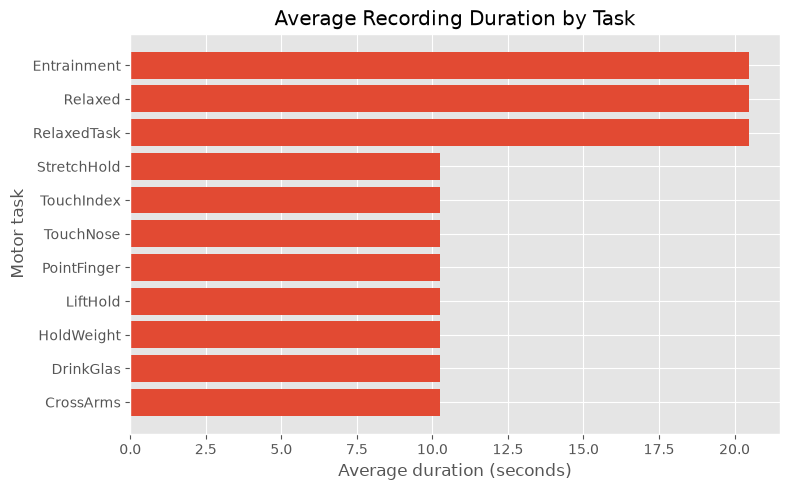

In [18]:
protocol = protocol.sort_values("Avg_Duration")

plt.figure(figsize=(8,5))
plt.barh(protocol.index, protocol["Avg_Duration"])

plt.xlabel("Average duration (seconds)")
plt.ylabel("Motor task")
plt.title("Average Recording Duration by Task")

plt.tight_layout()
plt.show()

# 3. Recording Completeness

Before processing the raw sensor signals, it is important to verify that each participant completed the expected motor assessment protocol. This section evaluates the completeness of the movement recordings by checking the number of tasks available for each participant.

In [19]:
tasks_per_patient = (
    movement_df
    .groupby("patient_id")["task"]
    .nunique()
)

tasks_per_patient.describe()

count    469.0
mean      11.0
std        0.0
min       11.0
25%       11.0
50%       11.0
75%       11.0
max       11.0
Name: task, dtype: float64

In [20]:
print(f"Expected tasks per participant : 11")
print(f"Minimum tasks observed         : {tasks_per_patient.min()}")
print(f"Maximum tasks observed         : {tasks_per_patient.max()}")
print(f"Participants with all tasks    : {(tasks_per_patient == 11).sum()}")
print(f"Incomplete participants        : {(tasks_per_patient < 11).sum()}")

Expected tasks per participant : 11
Minimum tasks observed         : 11
Maximum tasks observed         : 11
Participants with all tasks    : 469
Incomplete participants        : 0


# 4. Device Distribution

The movement recordings were acquired using Apple Watch devices. Since hardware characteristics may influence signal quality and sensor behavior, we summarize the distribution of recording devices included in the dataset.

This verification helps identify whether the dataset was collected using a single device generation or multiple smartwatch models.

In [21]:
device_counts = (
    movement_df["device"]
    .value_counts()
    .rename_axis("Device")
    .reset_index(name="Recordings")
)

device_counts

,Device,Recordings
0,Apple Watch Series 4,3674
1,Apple Watch Series 3,1485


In [22]:
fig = px.bar(
    device_counts,
    x="Device",
    y="Recordings",
    color="Device",
    text="Recordings",
    title="Distribution of Recording Devices"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    showlegend=False,
    yaxis_range=[0, device_counts["Recordings"].max() * 1.15]
)

fig.update_traces(textposition="outside")

fig.show()

# 5. Recording Samples Analysis

Each movement recording contains a fixed number of samples collected at a sampling frequency of 100 Hz. Therefore, the total number of samples determines the duration of each motor assessment.

This section verifies that each task contains the expected number of samples according to the acquisition protocol.

In [23]:
samples_summary = (
    movement_df
    .groupby("task")
    .agg(
        Samples=("samples", "mean"),
        Duration=("duration_seconds", "mean")
    )
    .round(2)
)

samples_summary

,Samples,Duration
task,,
CrossArms,1024.0,10.24
DrinkGlas,1024.0,10.24
Entrainment,2048.0,20.48
HoldWeight,1024.0,10.24
LiftHold,1024.0,10.24
...,...,...
Relaxed,2048.0,20.48
RelaxedTask,2048.0,20.48
StretchHold,1024.0,10.24


In [24]:
fig = px.bar(
    samples_summary.reset_index(),
    x="task",
    y="Samples",
    color="Samples",
    text="Samples",
    color_continuous_scale="Viridis",
    title="Average Number of Samples per Motor Task"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    coloraxis_showscale=False,
    xaxis_title="Motor Task",
    yaxis_title="Samples",
    yaxis_range=[0, 2300]
)

fig.update_traces(textposition="outside")

fig.show()

# 6. Metadata Quality Assessment

In [25]:
quality_summary = pd.DataFrame({
    "Validation Check": [
        "Missing values",
        "Duplicate records",
        "Participants",
        "Motor tasks",
        "Recording devices",
        "Sampling frequency",
        "Metadata completeness"
    ],
    "Result": [
        "None detected",
        "None detected",
        movement_df["patient_id"].nunique(),
        movement_df["task"].nunique(),
        movement_df["device"].nunique(),
        "100 Hz",
        "Passed"
    ]
})

quality_summary

,Validation Check,Result
0,Missing values,None detected
1,Duplicate records,None detected
2,Participants,469
3,Motor tasks,11
4,Recording devices,2
5,Sampling frequency,100 Hz
6,Metadata completeness,Passed


# 7. Conclusions

This notebook examined the structural metadata associated with the movement recordings of the Parkinson's Disease Smartwatch Dataset (PADS). The inspection confirms that the metadata is internally consistent and suitable for subsequent signal processing and machine learning analyses.

The main findings are summarized below:

- The movement metadata contains **5,159 recordings** collected from **469 participants** performing **11 standardized motor assessment tasks**.
- No missing values or duplicated records were identified, indicating that the metadata was successfully generated and imported without structural inconsistencies.
- All recordings were acquired at a uniform sampling frequency of **100 Hz**, ensuring consistency across participants and motor tasks.
- The dataset includes recordings collected using **Apple Watch Series 3** and **Apple Watch Series 4** devices, providing information about the acquisition hardware while maintaining a consistent recording protocol.
- Each motor task contains a fixed number of samples (**1,024** or **2,048**), corresponding to standardized recording durations of approximately **10.24** and **20.48 seconds**, respectively. No unexpected variability was observed within individual tasks.

Overall, the metadata inspection indicates that the dataset satisfies the basic quality requirements for downstream analyses. Consequently, the next stage of the project will focus on inspecting the raw inertial signals to evaluate signal quality, visualize movement patterns, and prepare the data for feature extraction and machine learning model development.